In [ ]:
from datetime import datetime
import socket

start = datetime.now()
print(f"Start time: {start}")
print(f"Host name: {socket.gethostname()}")

Start time: 2025-12-18 09:30:58.407549
Computer name: nid007026


# Setup, Imports & Load Data

In [23]:
# Environment detection and path setup
import sys
from pathlib import Path

# Detect if running in Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Colab-specific overrides
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/AML-ETH-Project2')
    # In Colab: src is directly in the project directory
    src_path = BASE_PATH / 'src'
else:
    current_dir = Path.cwd()
    BASE_PATH = current_dir.parent
    src_path = BASE_PATH / 'src'


print(f"Running in {'Colab' if IN_COLAB else 'local'} environment")
print(f"Base path: {BASE_PATH}")
print(f"src path: {src_path}")

# Add src to sys.path
sys.path.append(str(src_path))
print(f"Path '{src_path}' added to sys.path.")

Running in local environment
Base path: /users/lmantel/lab
src path: /users/lmantel/lab/src
Path '/users/lmantel/lab/src' added to sys.path.


In [24]:
# Standard library imports
import pickle
import gzip
import random
import os

# Scientific computing
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Progress bars
from tqdm.notebook import tqdm

# Widgets
import ipywidgets as widgets
from ipywidgets import IntSlider, FloatSlider, VBox

# Project-specific imports (require sys.path setup from Cell 0)
from models.UNet import UNet, initialize_weights
from train import train_one_epoch, eval_one_epoch
from dataset import FramesDataset
from utils.utilities import (
    make_train_test_split,
    preprocess_train_data,
    get_mask_from_image
)

print('Imports OK')

Imports OK


## Reproducibility Setup

Set random seeds for reproducibility across all random number generators.


In [25]:
# Reproducibility Setup
RANDOM_SEED = 42

# Set seeds for reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Make CUDA operations deterministic (may reduce performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set environment variable for additional reproducibility
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print(f'Reproducibility setup complete (seed={RANDOM_SEED})')


Reproducibility setup complete (seed=42)


### Helper functions

In [26]:
def load_zipped_pickle(filename):
    with gzip.open(filename, 'rb') as f:
        loaded_object = pickle.load(f)
        return loaded_object

def save_zipped_pickle(obj, filename):
    with gzip.open(filename, 'wb') as f:
        pickle.dump(obj, f, 2)

Example format of sample: { 'name': 'AC8ASN45B9', 'video': array([...], dtype='uint8'), 'box': array([...], dtype='bool'), 'label': array([...], dtype='bool'), 'frames': [41, 65, 167], 'dataset': 'amateur' }

In [27]:
# Adjust path to train.pkl if necessary
pkl_path = BASE_PATH / 'data' / 'raw' / 'train.pkl'

# Get entire dataset
data = load_zipped_pickle(str(pkl_path))

print('Number of samples:', len(data))

# Inspect a few samples (up to 3)
for i, sample in enumerate(data[:3]):
    print(f'Sample {i} name:', sample.get('name'))
    vid = sample.get('video')
    lab = sample.get('label')
    box = sample.get('box')
    print('  video: dtype=', getattr(vid, 'dtype', None), ' shape=', getattr(vid, 'shape', None))
    print('  label: dtype=', getattr(lab, 'dtype', None), ' shape=', getattr(lab, 'shape', None))
    print('  box:   dtype=', getattr(box, 'dtype', None), ' shape=', getattr(box, 'shape', None))
    print('  frames:', sample.get('frames'))

Number of samples: 65
Sample 0 name: D47OR19ANJ
  video: dtype= uint8  shape= (112, 112, 334)
  label: dtype= bool  shape= (112, 112, 334)
  box:   dtype= bool  shape= (112, 112)
  frames: [15, 59, 143]
Sample 1 name: IMNKTJV3OI
  video: dtype= uint8  shape= (112, 112, 177)
  label: dtype= bool  shape= (112, 112, 177)
  box:   dtype= bool  shape= (112, 112)
  frames: [2, 47, 79]
Sample 2 name: YSCCEISFRH
  video: dtype= uint8  shape= (112, 112, 195)
  label: dtype= bool  shape= (112, 112, 195)
  box:   dtype= bool  shape= (112, 112)
  frames: [18, 83, 131]


# Implement UNet Architecture

In [28]:
# UNet imports moved to Cell 4

# Training functions

In [29]:
# Training function imports moved to Cell 4

# Data structure for frames

In [30]:
# Dataset import moved to Cell 4

# Train model

In [31]:
# For now, data contains all videos labeled by amateurs. We do a 80/20 train/val split here.
# Split data into train and validation sets. We take validation data only from expert labeled videos.
# test_ratio refers to the fraction of expert labeled videos, NOT total videos.
train_data, val_data = make_train_test_split(data, test_ratio=0.2, random_seed=42)

# preprocess training data and validation data: extract frames and masks from data dicts
print("Preprocessing train data...")
names, frames, masks = preprocess_train_data(train_data)
val_names, val_frames, val_masks = preprocess_train_data(val_data)
# Make frames and masks single channel (H,W) So list has dimension (N, H, W) not (N, H, W, 1)
print(f"Processed {len(names)} training samples.")

# set up dataset and dataloader
train_ds = FramesDataset(frames, masks)
val_ds = FramesDataset(val_frames, val_masks)
print(f'Training Dataset size: {len(train_ds)}')
print(f'Validation Dataset size: {len(val_ds)}')

def seed_worker(worker_id):
    worker_seed = RANDOM_SEED % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_ds, 
    batch_size=8, 
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=generator
)
val_loader = DataLoader(
    val_ds, 
    batch_size=8, 
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=generator
)

# Set up model, optimizer, criterion, device
model = UNet(n_channels=1, n_classes=2)
initialize_weights(model)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device', device)
model = model.to(device)

Preprocessing train data...


100%|██████████| 3/3 [00:00<00:00, 35.76it/s]


Processed 186 training samples.
Training Dataset size: 186
Validation Dataset size: 9
Using device cuda


Overall Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 — train_loss: 0.119111, val_loss: 0.055016


Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19/20 — train_loss: 0.009449, val_loss: 0.020383


Training next epoch:   0%|          | 0/24 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 20/20 — train_loss: 0.009398, val_loss: 0.026536
Model saved to unet_mitral_valve.pth


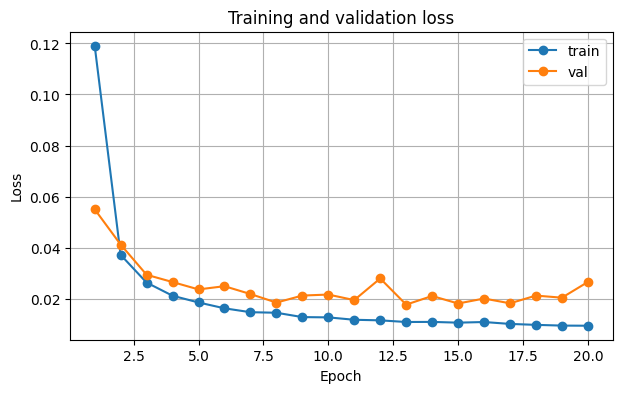

In [ ]:
# If train == True, Train for 20 epochs and plot epoch losses
# otherwise load saved weights
train = True
if train:
  epochs = 20
  train_losses = []
  val_losses = []

  pbar = tqdm(range(1, epochs+1), desc='Overall Training')
  for epoch in pbar:
      train_loss = train_one_epoch(model, train_loader, optim, criterion, device)
      val_loss = eval_one_epoch(model, val_loader, criterion, device)  # using val_loader
      train_losses.append(train_loss)
      val_losses.append(val_loss)
      print(f'Epoch {epoch}/{epochs} — train_loss: {train_loss:.6f}, val_loss: {val_loss:.6f}')
      pbar.set_postfix({'train_loss': train_loss, 'val_loss': val_loss})
  torch.save(model.state_dict(), 'unet_mitral_valve.pth')
  print('Model saved to unet_mitral_valve.pth')
  # Plot losses
  plt.figure(figsize=(7,4))
  plt.plot(range(1, epochs+1), train_losses, marker='o', label='train')
  plt.plot(range(1, epochs+1), val_losses, marker='o', label='val')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.ylim(bottom=0)
  plt.title('Training and validation loss')
  plt.legend()
  plt.grid(True)
  plt.show()
else:
  # Weights path: local vs. Colab
  weights_path = BASE_PATH / 'weights' / 'unet_weights_colab1.pth'
  if not weights_path.exists() and not IN_COLAB:
    # Fallback for local weights with different name
    weights_path = BASE_PATH / 'weights' / 'unet_weights.pth'
  if not weights_path.exists():
    raise FileNotFoundError(f'Weights not found: {weights_path}')
  model.load_state_dict(torch.load(str(weights_path)))
  print(f'Weights loaded from: {weights_path}')

# Model evaluation

We have to be careful how to scale our data when making predictions. Our model is trained to make predictions for 256 x 256 images. So to get a prediction for arbitrary images, we have to 1. rescale the image 2. get prediction mask 3. do the inverse rescaling of the mask to get prediction for the original image.

We first compute median Jaccard Index on val_data and then visualize the predicted masks on one of the videos in val_data

In [33]:
torch.save(model.state_dict(), 'unet_weights.pth')

In [34]:
# Compute median Jaccard Index (IoU) on val_loader (frame-level)
model.eval()
iou_scores = []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)  # (B,H,W)
        # per-sample IoU
        for p, t in zip(preds, masks):
            p_bin = p.bool()
            t_bin = t.bool()
            inter = (p_bin & t_bin).sum().item()
            union = (p_bin | t_bin).sum().item()
            if union == 0:
                iou = 1.0  # both empty
            else:
                iou = inter / union
            iou_scores.append(iou)

median_iou = float(np.median(iou_scores)) if iou_scores else float('nan')
print(f"Median IoU on val_loader: {median_iou:.4f} (n={len(iou_scores)} frames)")


Median IoU on val_loader: 0.3082 (n=9 frames)


Visualize masks for all frames of one sample video from validation data.

In [35]:
# Inference with slider: predict masks for all frames of first validation video and browse them
sample = val_data[1]
video = sample['video']  # shape assumed (H, W, T)

H, W, T = video.shape
num_frames = T // 2

# ensure model on device and eval
model = model.to(device)
model.eval()

# run inference for all frames (single-channel input assumed)
masks_pred = []

with torch.no_grad():
    for i in range(0, num_frames):
        frame = video[..., i].astype('float32') / 255.0  # (H,W)
        mask = get_mask_from_image(frame, model, 256, 256)  # (H,W) binary
        masks_pred.append(mask)

masks_pred = np.stack(masks_pred, axis=0)  # (T,H,W)
print('Predicted masks shape (T,H,W):', masks_pred.shape)

# slider to browse frames with overlay
frame_slider = IntSlider(min=0, max=num_frames-1, value=0, description='frame')

def show_pred_frame(t):
    plt.figure(figsize=(5,5))
    plt.imshow(video[..., t], cmap='gray')
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    rgba[..., 0] = 1.0
    rgba[..., 3] = masks_pred[t].astype(float) * 0.5
    plt.imshow(rgba, interpolation='nearest')
    plt.title(f"Frame {t} overlay")
    plt.axis('off')
    plt.show()

widgets.interact(show_pred_frame, t=frame_slider);

Predicted masks shape (T,H,W): (58, 579, 844)


interactive(children=(IntSlider(value=0, description='frame', max=57), Output()), _dom_classes=('widget-intera…

Visualize predicted mask, vs. label mask on validation data.

In [36]:
# Visualize val_loader predictions vs labels with a slider (all frames)
model.eval()
all_imgs = []
all_gts = []
all_preds = []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)  # (B,H,W)
        # move to cpu numpy
        all_imgs.append(imgs.cpu().numpy())        # (B,1,H,W)
        all_gts.append(masks.cpu().numpy())        # (B,H,W)
        all_preds.append(preds.cpu().numpy())      # (B,H,W)

# stack along batch dimension
imgs_np = np.concatenate(all_imgs, axis=0)   # (N,1,H,W)
gts_np = np.concatenate(all_gts, axis=0)     # (N,H,W)
preds_np = np.concatenate(all_preds, axis=0) # (N,H,W)
N, _, H, W = imgs_np.shape
print(f'Collected {N} frames from val_loader for visualization: shape (N,H,W)=({N},{H},{W})')

frame_slider = IntSlider(min=0, max=N-1, value=0, description='frame')

def show_overlay(i):
    img = imgs_np[i, 0]  # assume single channel
    gt = gts_np[i]
    pr = preds_np[i]
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap='gray')
    rgba = np.zeros((H, W, 4), dtype=np.float32)
    # green = label, red = prediction
    rgba[..., 1] = gt.astype(float)       # green channel
    rgba[..., 0] = pr.astype(float)       # red channel
    rgba[..., 3] = 0.45 * ((gt + pr) > 0).astype(float)  # alpha where either mask is present
    plt.imshow(rgba, interpolation='nearest')
    plt.title(f'Frame {i}: green=label, red=pred')
    plt.axis('off')
    plt.show()

widgets.interact(show_overlay, i=frame_slider);

Collected 9 frames from val_loader for visualization: shape (N,H,W)=(9,256,256)


interactive(children=(IntSlider(value=0, description='frame', max=8), Output()), _dom_classes=('widget-interac…

In [ ]:
end = datetime.now()
print(f"End time: {end}")
print(f"Duration: {end - start}")
print(f"Host name: {socket.gethostname()}")

End time: 2025-12-18 09:31:38.912785
Duration: 0:00:40.505236
Computer name: nid007026
